# SECTION 01

### Important Point
**Sometimes, as $X$ increases, $Y$ increases exponentially (like the spread of a virus or compound interest). We handle this by creating "Polynomial Features" (e.g., $x^2, x^3$).**

* While it is common to use Polynomial Features to model non-linear growth, this technique is typically best for curves that grow at a power rate (e.g., x^2 or x^3).
* For truly exponential growth, where the rate of increase is proportional to the current value (e.g., 2^x or e^x), researchers often use Logarithmic Transformations or Exponential Regression for a better fit.

* When growth is exponential **Y = a.e^(bX)**, the most effective approach is often to apply a natural logarithm to the \(Y\) variable.

*  This "linearizes" the relationship:**Y=ln(a)+bX**

* By training a linear model on ln(Y) instead of Y, you can capture exponential patterns using standard linear regression tools without needing high-degree polynomials.

Exponential params: a=1.86, b=0.51


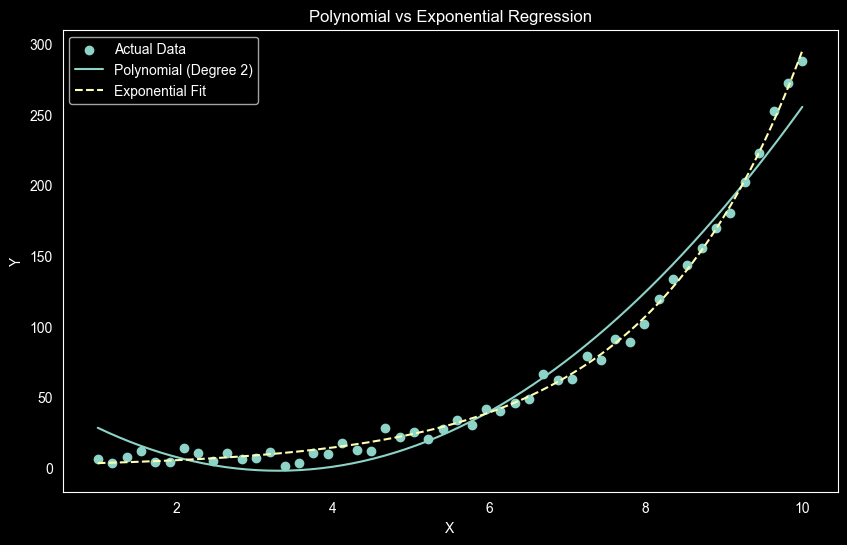

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from scipy.optimize import curve_fit

# Generate synthetic exponential data
np.random.seed(42)
x = np.linspace(1, 10, 50)
y = 2 * np.exp(0.5 * x) + np.random.normal(0, 5, len(x))

# Reshape
x_reshaped = x.reshape(-1, 1)

# -------------------------------
# 1. Polynomial Regression
# -------------------------------
poly_feat = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly_feat.fit_transform(x_reshaped)

poly_model = LinearRegression()
poly_model.fit(x_poly, y)

# Smooth curve points
x_smooth = np.linspace(1, 10, 200)
x_smooth_reshaped = x_smooth.reshape(-1, 1)
x_smooth_poly = poly_feat.transform(x_smooth_reshaped)

y_poly_pred = poly_model.predict(x_smooth_poly)

# -------------------------------
# 2. Exponential Regression
# -------------------------------
def exp_func(x, a, b):
    return a * np.exp(b * x)

popt, _ = curve_fit(exp_func, x, y)
y_exp_pred = exp_func(x_smooth, *popt)

print(f"Exponential params: a={popt[0]:.2f}, b={popt[1]:.2f}")

# -------------------------------
# 3. Plot Comparison
# -------------------------------
plt.figure(figsize=(10,6))

# Actual data
plt.scatter(x, y, label="Actual Data")

# Polynomial curve
plt.plot(x_smooth, y_poly_pred, label="Polynomial (Degree 2)")

# Exponential curve
plt.plot(x_smooth, y_exp_pred, linestyle='--', label="Exponential Fit")

plt.title("Polynomial vs Exponential Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid()

plt.show()

Exponential params: a=1.86, b=0.51


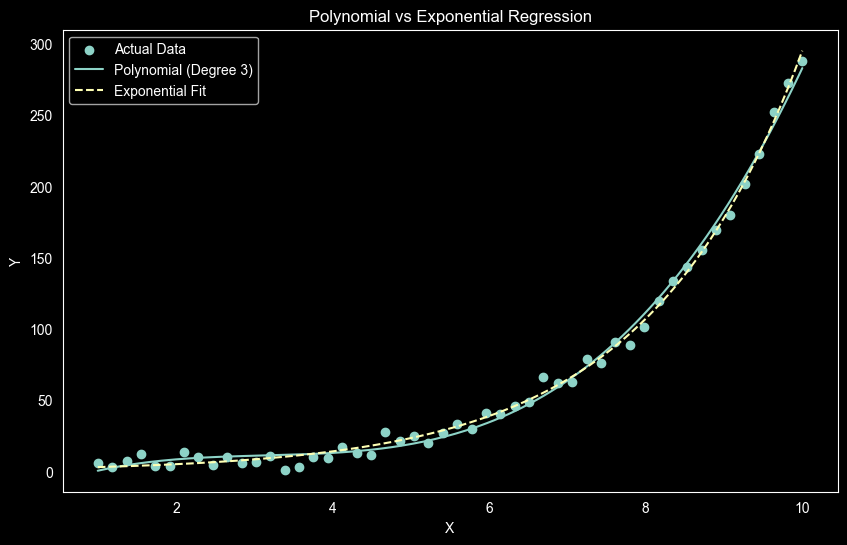

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from scipy.optimize import curve_fit

# Generate synthetic exponential data
np.random.seed(42)
x = np.linspace(1, 10, 50)
y = 2 * np.exp(0.5 * x) + np.random.normal(0, 5, len(x))

# Reshape
x_reshaped = x.reshape(-1, 1)

# -------------------------------
# 1. Polynomial Regression
# -------------------------------
poly_feat = PolynomialFeatures(degree=3, include_bias=False)
x_poly = poly_feat.fit_transform(x_reshaped)

poly_model = LinearRegression()
poly_model.fit(x_poly, y)

# Smooth curve points
x_smooth = np.linspace(1, 10, 200)
x_smooth_reshaped = x_smooth.reshape(-1, 1)
x_smooth_poly = poly_feat.transform(x_smooth_reshaped)

y_poly_pred = poly_model.predict(x_smooth_poly)

# -------------------------------
# 2. Exponential Regression
# -------------------------------
def exp_func(x, a, b):
    return a * np.exp(b * x)

popt, _ = curve_fit(exp_func, x, y)
y_exp_pred = exp_func(x_smooth, *popt)

print(f"Exponential params: a={popt[0]:.2f}, b={popt[1]:.2f}")

# -------------------------------
# 3. Plot Comparison
# -------------------------------
plt.figure(figsize=(10,6))

# Actual data
plt.scatter(x, y, label="Actual Data")

# Polynomial curve
plt.plot(x_smooth, y_poly_pred, label="Polynomial (Degree 3)")

# Exponential curve
plt.plot(x_smooth, y_exp_pred, linestyle='--', label="Exponential Fit")

plt.title("Polynomial vs Exponential Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid()
plt.show()

## OBSERVATIONS (Polynomial Degree 3 vs Exponential)

### 1. Data Pattern
* The dataset clearly follows an exponential growth trend
* Y increases slowly at first and then rapidly at higher X values

### 2. Polynomial Regression (Degree 3)
Produces a smooth and flexible curve

**Compared to degree 2, it:**
Fits the data much better across the full range captures curvature more effectively

**At higher X values:**
* Closely follows the data
* Slight deviation may still exist


### 3. Exponential Regression
* Continues to perfectly align with the data
* Captures the true growth behavior
* Matches both low and high regions accurately

### 4. Comparison Insight

**Degree 3 Polynomial:**
* Now very close to exponential curve
* Acts as a strong approximation
*
**Exponential Model:**
* Still more theoretically correct
* Better for true exponential data

### 5. Model Behavior
**Polynomial (degree 3):**
* It fits the data much better than degree 2
* Able to model get relationship effectively
* The curve resembles exponential growth

**Polynomial (4 degree):**
* Curve tries to catch every point of data It may Overfit
